<a href="https://colab.research.google.com/github/zuynali/Pytorch/blob/main/01_pytorch_workflow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
from torch import nn
import matplotlib.pyplot as plt


###nn contains all of Pytorch's building block of neural networks


In [2]:
weight =0.7
bias =0.3
start =0
end=1
step=0.02
X=torch.arange(start,end,step).unsqueeze(dim=1)
y=weight*X+bias
X[:10],y[:10],len(X),len(y)

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]),
 50,
 50)

In [3]:
train_split=int(0.8*len(X))
train_split
X_train,y_train=X[:train_split],y[:train_split]
X_test,y_test=X[train_split:],y[train_split:]
X_train,y_train

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800],
         [0.2000],
         [0.2200],
         [0.2400],
         [0.2600],
         [0.2800],
         [0.3000],
         [0.3200],
         [0.3400],
         [0.3600],
         [0.3800],
         [0.4000],
         [0.4200],
         [0.4400],
         [0.4600],
         [0.4800],
         [0.5000],
         [0.5200],
         [0.5400],
         [0.5600],
         [0.5800],
         [0.6000],
         [0.6200],
         [0.6400],
         [0.6600],
         [0.6800],
         [0.7000],
         [0.7200],
         [0.7400],
         [0.7600],
         [0.7800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260],
         [0.4400],
         [0.4540],
         [

In [4]:
def plot_pred(train_data=X_train,train_labels=y_train,test_data=X_test,test_labels=y_test,pred=None):
  plt.figure(figsize=(10,7))
  plt.scatter(train_data,train_labels,c='b',s=4,label='Training data')
  plt.scatter(test_data,test_labels,c='g',s=4,label='Testing data')

  if pred is not None:
    plt.scatter(test_data,pred,c='r',s=4,label='Predictions')

  plt.legend(prop={'size':14})

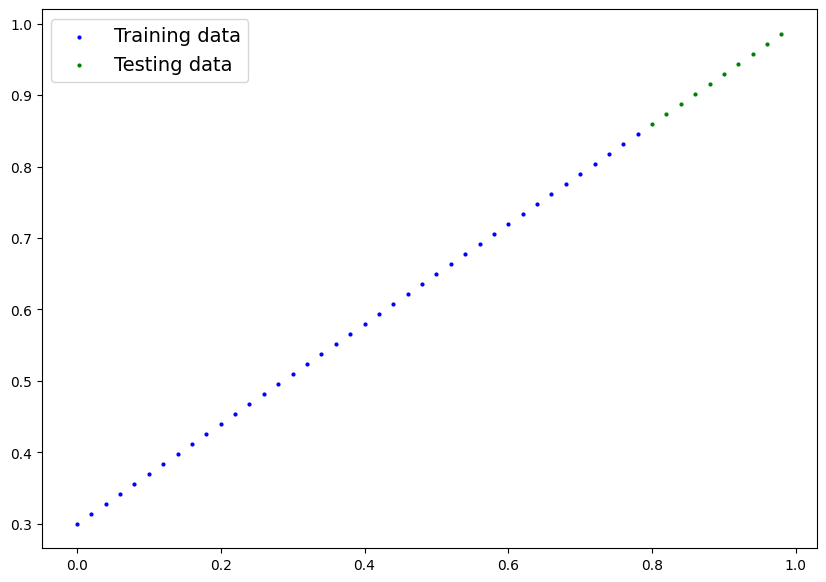

In [5]:
plot_pred()

In [6]:
class LinearRegression(nn.Module):
  def __init__(self):
    super().__init__()
    self.weights=nn.Parameter(torch.randn(1,requires_grad=True,dtype=torch.float))
    self.bias=nn.Parameter(torch.randn(1,requires_grad=True,dtype=torch.float))

  def forward(self,x:torch.Tensor)->torch.Tensor :
    return self.weights * x+ self.bias

In [7]:
torch.manual_seed(42)
model_0=LinearRegression()
list(model_0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [8]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])

In [9]:
with torch.inference_mode():
  y_pred=model_0(X_test)
y_pred,y_test

(tensor([[0.3982],
         [0.4049],
         [0.4116],
         [0.4184],
         [0.4251],
         [0.4318],
         [0.4386],
         [0.4453],
         [0.4520],
         [0.4588]]),
 tensor([[0.8600],
         [0.8740],
         [0.8880],
         [0.9020],
         [0.9160],
         [0.9300],
         [0.9440],
         [0.9580],
         [0.9720],
         [0.9860]]))

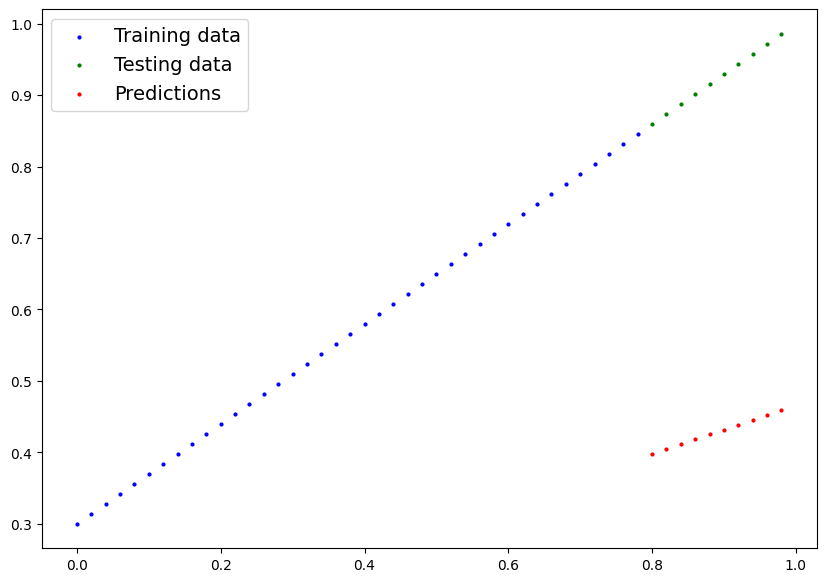

In [10]:
plot_pred(pred=y_pred)

In [11]:
loss_fn=nn.L1Loss()

opt= torch.optim.SGD(params=model_0.parameters(),lr=0.01)

In [12]:
epochs=200

epoch_count=[]
loss_values=[]
test_loss_values=[]


for epoch in range(epochs):
  model_0.train()
  y_pred=model_0(X_train)
  loss=loss_fn(y_pred,y_train)
  opt.zero_grad()
  loss.backward()
  opt.step()

  model_0.eval()
  with torch.inference_mode():
    test_pred=model_0(X_test)

  test_loss=loss_fn(test_pred,y_test)

  if epoch % 10==0:
    epoch_count.append(epoch)
    loss_values.append(loss)
    test_loss_values.append(test_loss)
    print(f'{epoch}|{loss}|{test_loss}')
    print(model_0.state_dict())

0|0.31288138031959534|0.48106518387794495
OrderedDict({'weights': tensor([0.3406]), 'bias': tensor([0.1388])})
10|0.1976713240146637|0.3463551998138428
OrderedDict({'weights': tensor([0.3796]), 'bias': tensor([0.2388])})
20|0.08908725529909134|0.21729660034179688
OrderedDict({'weights': tensor([0.4184]), 'bias': tensor([0.3333])})
30|0.053148526698350906|0.14464017748832703
OrderedDict({'weights': tensor([0.4512]), 'bias': tensor([0.3768])})
40|0.04543796554207802|0.11360953003168106
OrderedDict({'weights': tensor([0.4748]), 'bias': tensor([0.3868])})
50|0.04167863354086876|0.09919948130846024
OrderedDict({'weights': tensor([0.4938]), 'bias': tensor([0.3843])})
60|0.03818932920694351|0.08886633068323135
OrderedDict({'weights': tensor([0.5116]), 'bias': tensor([0.3788])})
70|0.03476089984178543|0.0805937647819519
OrderedDict({'weights': tensor([0.5288]), 'bias': tensor([0.3718])})
80|0.03132382780313492|0.07232122868299484
OrderedDict({'weights': tensor([0.5459]), 'bias': tensor([0.3648

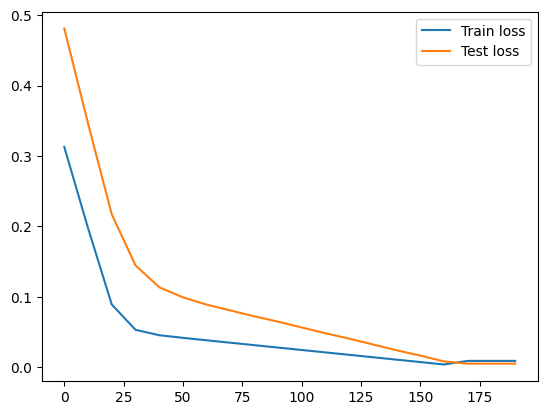

In [19]:
import numpy as np

plt.plot(epoch_count,(torch.tensor(loss_values).numpy()),label='Train loss')
plt.plot(epoch_count,test_loss_values,label='Test loss')
plt.legend()

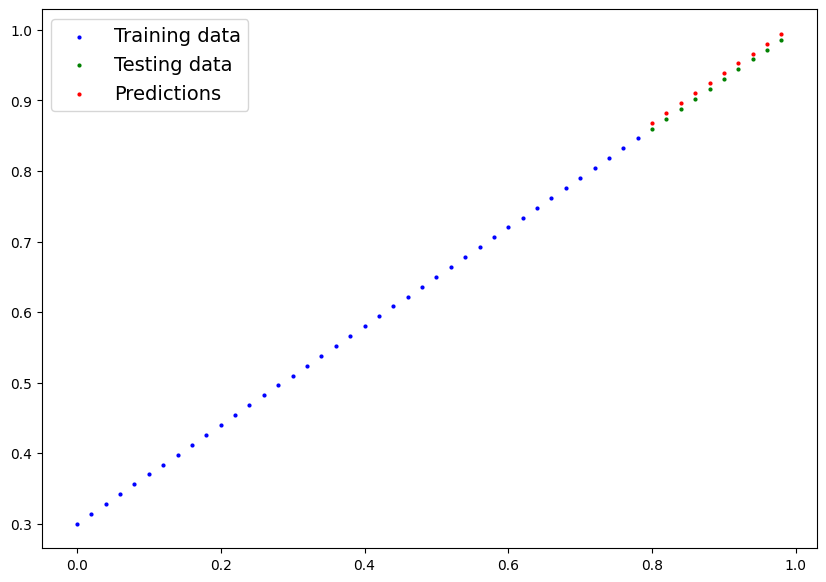

In [20]:
with torch.inference_mode():
  y_pred2=model_0(X_test)

plot_pred(pred=y_pred2)

In [21]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.6990])), ('bias', tensor([0.3093]))])

In [27]:
from pathlib import Path
model_path =Path("models")
model_path.mkdir(parents=True,exist_ok=True)
model_name='model_0.pth'
model_save=model_path/model_name

PosixPath('models/model_0.pth')

In [30]:
torch.save(obj=model_0.state_dict(),f=model_save)